***Tutorial***

---



In [ ]:
# Step 1 Import Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# Step 2 Construct the Backbone
def build_backbone(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    return keras.Model(inputs=inputs, outputs=x)

backbone = build_backbone()

# Step 3: Constructing the Region Proposal Network (RPN)
def build_rpn(feature_map):
    conv = keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu')(feature_map)
    rpn_class = keras.layers.Conv2D(9 * 2, (1, 1), activation='sigmoid')(conv)  # 9 anchors, classification (obj/non-obj)
    rpn_class = keras.layers.Reshape((-1, 2))(rpn_class)
    rpn_bbox = keras.layers.Conv2D(9 * 4, (1, 1))(conv)  # 9 anchors, 4 bounding box values
    rpn_bbox = keras.layers.Reshape((-1, 4))(rpn_bbox)
    return rpn_class, rpn_bbox

# Step 4: Implement the ROI pooling layer
class ROIPoolingLayer(keras.layers.Layer):
    def __init__(self, pool_size, **kwargs):
        super(ROIPoolingLayer, self).__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, rois = inputs
        rois = tf.cast(rois, tf.float32)
        batch_indices = tf.zeros((tf.shape(rois)[0]), dtype=tf.int32)
        pooled_rois = tf.image.crop_and_resize(
            feature_map, rois, box_indices=batch_indices, crop_size=self.pool_size
        )
        return pooled_rois

    def compute_output_shape(self, input_shape):
        feature_map_shape, rois_shape = input_shape
        num_rois = rois_shape[0]
        return (num_rois, self.pool_size[0], self.pool_size[1], feature_map_shape[-1])

roi_pooling_layer = ROIPoolingLayer((7, 7))

# Step 5: Create Classification and Regression Heads
def build_heads(pooled_rois, num_classes):
    flatten = keras.layers.Flatten()(pooled_rois)
    dense1 = keras.layers.Dense(1024, activation='relu')(flatten)
    dense2 = keras.layers.Dense(1024, activation='relu')(dense1)
    classifier = keras.layers.Dense(num_classes, activation='softmax')(dense2)
    bbox_regressor = keras.layers.Dense(num_classes * 4, activation=None)(dense2)  # 4 values per bounding box
    return classifier, bbox_regressor

# Step 6: Assembling the Complete Faster R-CNN Model
def build_faster_rcnn(input_shape, num_classes):
    input_image = keras.Input(shape=input_shape)
    rois = keras.Input(shape=(None, 4))  # Input for rois
    feature_map = backbone(input_image)
    rpn_class, rpn_bbox = build_rpn(feature_map)
    pooled_rois = roi_pooling_layer([feature_map, rois])
    classifier, bbox_regressor = build_heads(pooled_rois, num_classes)
    model = keras.Model(inputs=[input_image, rois], outputs=[rpn_class, rpn_bbox, classifier, bbox_regressor])
    return model

# Step 7: Printing Summary of the model
num_classes = 80  # Example number of classes for COCO dataset
faster_rcnn = build_faster_rcnn((224, 224, 3), num_classes)
faster_rcnn.summary()

# Step 8: Calculating IOU
def calculate_iou(box1, box2):
    ymin1, xmin1, ymax1, xmax1 = box1
    ymin2, xmin2, ymax2, xmax2 = box2
    inter_xmin = max(xmin1, xmin2)
    inter_ymin = max(ymin1, ymin2)
    inter_xmax = min(xmax1, xmax2)
    inter_ymax = min(ymax1, ymax2)
    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    area1 = (xmax1 - xmin1) * (ymax1 - ymin1)
    area2 = (xmax2 - xmin2) * (ymax2 - ymin2)
    union_area = area1 + area2 - inter_area
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

# Step 9: Calculating Precision & Recall
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_threshold=0.5):
    tp, fp = 0, 0
    matched_gt = set()
    for pred_index, pred_box in enumerate(pred_boxes):
        best_iou = 0
        best_gt = -1
        for gt_index, gt_box in enumerate(gt_boxes):
            if pred_labels[pred_index] == gt_labels[gt_index] and gt_index not in matched_gt:
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt_index
        if best_iou > iou_threshold:
            tp += 1
            matched_gt.add(best_gt)
        else:
            fp += 1
    fn = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall

# Step 10: Calculating Average Precision & mAP
def calculate_ap(precisions, recalls):
    precisions = [0] + precisions + [0]
    recalls = [0] + recalls + [1]
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i-1] = max(precisions[i-1], precisions[i])
    ap = sum((recalls[i] - recalls[i-1]) * precisions[i] for i in range(1, len(precisions)))
    return ap
# Calculate Mean Average Precision (mAP) Axross all classes
def calculate_map(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, num_classes, iou_threshold=0.5):
    average_precisions = []
    for class_id in range(num_classes):  # Iterate through all classes
        class_pred_boxes = [pred_boxes[i] for i in range(len(pred_boxes)) if pred_labels[i] == class_id]
        class_pred_scores = [pred_scores[i] for i in range(len(pred_scores)) if pred_labels[i] == class_id]
        class_gt_boxes = [gt_boxes[i] for i in range(len(gt_boxes)) if gt_labels[i] == class_id]

        if not class_gt_boxes:  # Skip if no ground truth boxes for this class
            continue

        # Sort predictions by score descending
        indices = np.argsort(-np.array(class_pred_scores))
        class_pred_boxes = [class_pred_boxes[i] for i in indices]
        class_pred_scores = [class_pred_scores[i] for i in indices]

        tp, fp = 0, 0
        matched_gt = set()
        precisions, recalls = [], []

        for i, (pred_box, pred_score) in enumerate(zip(class_pred_boxes, class_pred_scores)):
            best_iou = 0
            best_gt_index = -1

            for gt_index, gt_box in enumerate(class_gt_boxes):
                if gt_index in matched_gt:
                    continue
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_index = gt_index

            if best_iou >= iou_threshold:
                tp += 1
                matched_gt.add(best_gt_index)
            else:
                fp += 1

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / len(class_gt_boxes)
            precisions.append(precision)
            recalls.append(recall)

        if precisions and recalls:
          average_precisions.append(calculate_ap(precisions, recalls))

    map_ = np.mean(average_precisions) if average_precisions else 0
    return map_


# Step 11: Sample Values for Obtaining mAP
pred_boxes = [[0.1, 0.1, 0.4, 0.4], [0.5, 0.5, 0.8, 0.8], [0.3, 0.3, 0.6, 0.6], [0.7, 0.7, 0.9, 0.9], [0.2, 0.2, 0.5, 0.5]]
pred_scores = [0.9, 0.8, 0.7, 0.6, 0.5]
pred_labels = [1, 1, 1, 1, 1]
gt_boxes = [[0.12, 0.12, 0.42, 0.42], [0.52, 0.52, 0.82, 0.82], [0.9, 0.9, 0.99, 0.99]]
gt_labels = [1, 1, 2]
num_classes = 80  # (e.g., 80 for COCO)
# Calculate mAP
mean_ap = calculate_map(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, num_classes)
print("Mean Average Precision (mAP):", mean_ap)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 28, 28,    │     93,248 │ input_layer_1[0]… │
│ (Functional)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, None, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer   │ (None, 7, 7, 128) │          0 │ functional[0][0], │
│ (ROIPoolingLayer)   │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6272)      │          0 │ roi_pooling_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    590,336 │ functional[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │  6,423,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      9,234 │ conv2d_3[0][0]    │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     18,468 │ conv2d_3[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  1,049,600 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7056, 2)   │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7056, 4)   │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 80)        │     82,000 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 320)       │    328,000 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,594,438 (32.79 MB)

 Trainable params: 8,594,438 (32.79 MB)

 Non-trainable params: 0 (0.00 B)

Mean Average Precision (mAP): 1.0


***Task1***

---



After addeing 4th convolutional & pooling layer the number of parameters increased

In [ ]:
# Step 1 Import Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# Step 2 Construct the Backbone
def build_backbone(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    return keras.Model(inputs=inputs, outputs=x)

backbone = build_backbone()

# Step 3: Constructing the Region Proposal Network (RPN)
def build_rpn(feature_map):
    conv = keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu')(feature_map)
    rpn_class = keras.layers.Conv2D(9 * 2, (1, 1), activation='sigmoid')(conv)  # 9 anchors, classification (obj/non-obj)
    rpn_class = keras.layers.Reshape((-1, 2))(rpn_class)
    rpn_bbox = keras.layers.Conv2D(9 * 4, (1, 1))(conv)  # 9 anchors, 4 bounding box values
    rpn_bbox = keras.layers.Reshape((-1, 4))(rpn_bbox)
    return rpn_class, rpn_bbox

# Step 4: Implement the ROI pooling layer
class ROIPoolingLayer(keras.layers.Layer):
    def __init__(self, pool_size, **kwargs):
        super(ROIPoolingLayer, self).__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, rois = inputs
        rois = tf.cast(rois, tf.float32)
        batch_indices = tf.zeros((tf.shape(rois)[0]), dtype=tf.int32)
        pooled_rois = tf.image.crop_and_resize(
            feature_map, rois, box_indices=batch_indices, crop_size=self.pool_size
        )
        return pooled_rois

    def compute_output_shape(self, input_shape):
        feature_map_shape, rois_shape = input_shape
        num_rois = rois_shape[0]
        return (num_rois, self.pool_size[0], self.pool_size[1], feature_map_shape[-1])

roi_pooling_layer = ROIPoolingLayer((7, 7))

# Step 5: Create Classification and Regression Heads
def build_heads(pooled_rois, num_classes):
    flatten = keras.layers.Flatten()(pooled_rois)
    dense1 = keras.layers.Dense(1024, activation='relu')(flatten)
    dense2 = keras.layers.Dense(1024, activation='relu')(dense1)
    classifier = keras.layers.Dense(num_classes, activation='softmax')(dense2)
    bbox_regressor = keras.layers.Dense(num_classes * 4, activation=None)(dense2)  # 4 values per bounding box
    return classifier, bbox_regressor

# Step 6: Assembling the Complete Faster R-CNN Model
def build_faster_rcnn(input_shape, num_classes):
    input_image = keras.Input(shape=input_shape)
    rois = keras.Input(shape=(None, 4))  # Input for rois
    feature_map = backbone(input_image)
    rpn_class, rpn_bbox = build_rpn(feature_map)
    pooled_rois = roi_pooling_layer([feature_map, rois])
    classifier, bbox_regressor = build_heads(pooled_rois, num_classes)
    model = keras.Model(inputs=[input_image, rois], outputs=[rpn_class, rpn_bbox, classifier, bbox_regressor])
    return model

# Step 7: Printing Summary of the model
num_classes = 80  # Example number of classes for COCO dataset
faster_rcnn = build_faster_rcnn((224, 224, 3), num_classes)
faster_rcnn.summary()

# Step 8: Calculating IOU
def calculate_iou(box1, box2):
    ymin1, xmin1, ymax1, xmax1 = box1
    ymin2, xmin2, ymax2, xmax2 = box2
    inter_xmin = max(xmin1, xmin2)
    inter_ymin = max(ymin1, ymin2)
    inter_xmax = min(xmax1, xmax2)
    inter_ymax = min(ymax1, ymax2)
    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    area1 = (xmax1 - xmin1) * (ymax1 - ymin1)
    area2 = (xmax2 - xmin2) * (ymax2 - ymin2)
    union_area = area1 + area2 - inter_area
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

# Step 9: Calculating Precision & Recall
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_threshold=0.5):
    tp, fp = 0, 0
    matched_gt = set()
    for pred_index, pred_box in enumerate(pred_boxes):
        best_iou = 0
        best_gt = -1
        for gt_index, gt_box in enumerate(gt_boxes):
            if pred_labels[pred_index] == gt_labels[gt_index] and gt_index not in matched_gt:
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt_index
        if best_iou > iou_threshold:
            tp += 1
            matched_gt.add(best_gt)
        else:
            fp += 1
    fn = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall

# Step 10: Calculating Average Precision & mAP
def calculate_ap(precisions, recalls):
    precisions = [0] + precisions + [0]
    recalls = [0] + recalls + [1]
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i-1] = max(precisions[i-1], precisions[i])
    ap = sum((recalls[i] - recalls[i-1]) * precisions[i] for i in range(1, len(precisions)))
    return ap

def calculate_map(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, num_classes, iou_threshold=0.5):
    average_precisions = []
    for class_id in range(num_classes):  # Iterate through all classes
        class_pred_boxes = [pred_boxes[i] for i in range(len(pred_boxes)) if pred_labels[i] == class_id]
        class_pred_scores = [pred_scores[i] for i in range(len(pred_scores)) if pred_labels[i] == class_id]
        class_gt_boxes = [gt_boxes[i] for i in range(len(gt_boxes)) if gt_labels[i] == class_id]

        if not class_gt_boxes:  # Skip if no ground truth boxes for this class
            continue

        # Sort predictions by score descending
        indices = np.argsort(-np.array(class_pred_scores))
        class_pred_boxes = [class_pred_boxes[i] for i in indices]
        class_pred_scores = [class_pred_scores[i] for i in indices]

        tp, fp = 0, 0
        matched_gt = set()
        precisions, recalls = [], []

        for i, (pred_box, pred_score) in enumerate(zip(class_pred_boxes, class_pred_scores)):
            best_iou = 0
            best_gt_index = -1

            for gt_index, gt_box in enumerate(class_gt_boxes):
                if gt_index in matched_gt:
                    continue
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_index = gt_index

            if best_iou >= iou_threshold:
                tp += 1
                matched_gt.add(best_gt_index)
            else:
                fp += 1

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / len(class_gt_boxes)
            precisions.append(precision)
            recalls.append(recall)

        if precisions and recalls:
          average_precisions.append(calculate_ap(precisions, recalls))

    map_ = np.mean(average_precisions) if average_precisions else 0
    return map_


# Step 11: Sample Values for Obtaining mAP
pred_boxes = [[0.1, 0.1, 0.4, 0.4], [0.5, 0.5, 0.8, 0.8], [0.3, 0.3, 0.6, 0.6], [0.7, 0.7, 0.9, 0.9], [0.2, 0.2, 0.5, 0.5]]
pred_scores = [0.9, 0.8, 0.7, 0.6, 0.5]
pred_labels = [1, 1, 1, 1, 1]
gt_boxes = [[0.12, 0.12, 0.42, 0.42], [0.52, 0.52, 0.82, 0.82], [0.9, 0.9, 0.99, 0.99]]
gt_labels = [1, 1, 2]
num_classes = 80  # (e.g., 80 for COCO)
# Calculate mAP
mean_ap = calculate_map(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, num_classes)
print("Mean Average Precision (mAP):", mean_ap)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 14, 14,    │    388,416 │ input_layer_1[0]… │
│ (Functional)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, None, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer   │ (None, 7, 7, 256) │          0 │ functional[0][0], │
│ (ROIPoolingLayer)   │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12544)     │          0 │ roi_pooling_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │  1,180,160 │ functional[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │ 12,846,080 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │      9,234 │ conv2d_4[0][0]    │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │     18,468 │ conv2d_4[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  1,049,600 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1764, 2)   │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1764, 4)   │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 80)        │     82,000 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 320)       │    328,000 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,901,958 (60.66 MB)

 Trainable params: 15,901,958 (60.66 MB)

 Non-trainable params: 0 (0.00 B)

Mean Average Precision (mAP): 1.0


***Task2***

---



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 28, 28,    │  1,550,976 │ input_layer_3[0]… │
│ (Functional)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, None, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer_1 │ (None, None, 7,   │          0 │ functional_2[0][… │
│ (ROIPoolingLayer)   │ 7, 512)           │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, None,      │          0 │ roi_pooling_laye… │
│ (TimeDistributed)   │ 25088)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 28, 28,    │  2,359,808 │ functional_2[0][… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, None,      │ 25,691,136 │ time_distributed… │
│ (TimeDistributed)   │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 28, 28,    │      9,234 │ conv2d_11[0][0]   │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 28, 28,    │     18,468 │ conv2d_11[0][0]   │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, None, 80)  │     82,000 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, None, 320) │    328,000 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,039,622 (114.59 MB)

 Trainable params: 30,039,622 (114.59 MB)

 Non-trainable params: 0 (0.00 B)


 Running Task 2 Test on: cat.png 

 Visualization Results when model is untrained
Dummy Box 0: Randomly guessed 'bowl' with 0.69 confidence.
Dummy Box 1: Randomly guessed 'bowl' with 0.71 confidence.
Dummy Box 2: Randomly guessed 'tie' with 0.63 confidence.


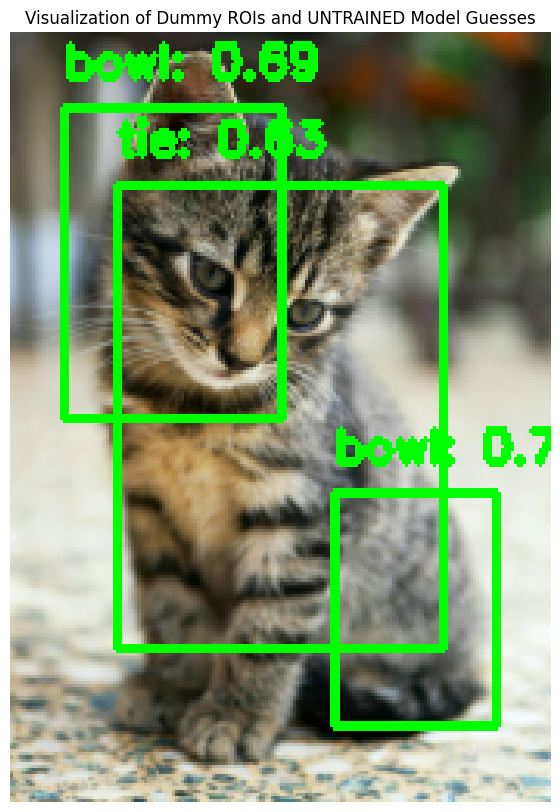

In [2]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# Added COCO Class names
COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow", "elephant",
    "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard",
    "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle",
    "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
    "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant", "bed", "dining table", "toilet",
    "tv", "laptop", "mouse", "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator",
    "book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

# Step 2: Construct the Backbone
def build_backbone(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(256, (3, 3), activation="relu", padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    outputs = keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    return keras.Model(inputs, outputs)

# Step 3: Constructing the Region Proposal Network (RPN)
def build_rpn(feature_map):
    rpn_conv = keras.layers.Conv2D(512, (3, 3), padding="same", activation="relu")(feature_map)
    rpn_class = keras.layers.Conv2D(9 * 2, (1, 1), activation="sigmoid")(rpn_conv)
    rpn_bbox = keras.layers.Conv2D(9 * 4, (1, 1))(rpn_conv)
    return rpn_class, rpn_bbox

# Step 4: Implement the ROI pooling layer
class ROIPoolingLayer(tf.keras.layers.Layer):
    def __init__(self, pool_size, **kwargs):
        super(ROIPoolingLayer, self).__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, rois = inputs

        # This layer expects ROIs with a batch dimension: (batch_size, num_rois, 4)
        # We need to unstack the batch dimension to use tf.image.crop_and_resize

        # Get shape info
        batch_size = tf.shape(feature_map)[0]
        num_rois = tf.shape(rois)[1]

        # Flatten ROIs and add batch indices
        rois_flat = tf.reshape(rois, [-1, 4])

        # Create batch_indices [0, 0, 0, ..., 1, 1, 1, ..., 2, 2, 2, ...]
        batch_indices = tf.repeat(tf.range(batch_size), num_rois)

        pooled_rois = tf.image.crop_and_resize(
            feature_map, boxes=rois_flat, box_indices=batch_indices, crop_size=self.pool_size
        )

        # Reshape back to (batch_size * num_rois, pool_height, pool_width, channels)
        # The heads will expect (batch_size, num_rois, pool_height, pool_width, channels)
        # after we reshape.
        final_shape = (batch_size, num_rois, self.pool_size[0], self.pool_size[1], tf.shape(feature_map)[-1])
        pooled_rois = tf.reshape(pooled_rois, final_shape)

        return pooled_rois

    def compute_output_shape(self, input_shape):
        feature_map_shape, rois_shape = input_shape
        batch_size = feature_map_shape[0]
        num_rois = rois_shape[1]
        channels = feature_map_shape[-1]
        return (batch_size, num_rois, self.pool_size[0], self.pool_size[1], channels)

# Step 5: Create Classification and Regression Heads
def build_heads(pooled_rois, num_classes):
    # TimeDistributed wrapper applies the layers to each ROI independently
    flatten = keras.layers.TimeDistributed(keras.layers.Flatten())(pooled_rois)
    dense = keras.layers.TimeDistributed(keras.layers.Dense(1024, activation="relu"))(flatten)
    classifier = keras.layers.TimeDistributed(keras.layers.Dense(num_classes, activation="softmax"))(dense)
    bbox_regressor = keras.layers.TimeDistributed(keras.layers.Dense(num_classes * 4))(dense)
    return classifier, bbox_regressor

# Step 6: Assembling the Complete Faster R-CNN Model
def build_faster_rcnn(num_classes, input_shape=(224, 224, 3)):
    input_image = keras.Input(shape=input_shape)
    rois = keras.Input(shape=(None, 4)) # ROIs Input, (batch_size, num_rois, 4)

    backbone = build_backbone(input_shape)
    feature_map = backbone(input_image)

    rpn_class, rpn_bbox = build_rpn(feature_map)

    roi_pooling_layer = ROIPoolingLayer((7, 7))
    pooled_rois = roi_pooling_layer([feature_map, rois])

    classifier, bbox_regressor = build_heads(pooled_rois, num_classes)

    model = keras.Model(inputs=[input_image, rois], outputs=[rpn_class, rpn_bbox, classifier, bbox_regressor])
    return model

# Step 7: Printing Summary of the model
num_classes = 80
faster_rcnn = build_faster_rcnn(num_classes)
faster_rcnn.summary()


#                             Implementation of Task 2

# This function now returns the dummy_rois as well, so we can draw them
def test_random_image(image_path, model):
    # 1. Load and preprocess the image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}. Please check the file path.")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image_rgb, (224, 224))
    input_tensor = tf.convert_to_tensor(resized_image, dtype=tf.float32)
    input_tensor = input_tensor[tf.newaxis, ...]

    # 2. Create Dummy ROIs
    dummy_rois = tf.constant([
        [0.1, 0.1, 0.5, 0.5],  # Top-left box
        [0.6, 0.6, 0.9, 0.9],  # Bottom-right box
        [0.2, 0.2, 0.8, 0.8]   # Middle box
    ], dtype=tf.float32)

    # Add batch dimension
    dummy_rois_batch = dummy_rois[tf.newaxis, ...]

    # 3. Run the model
    outputs = model([input_tensor, dummy_rois_batch])

    # Return the model outputs AND the rois we used
    return outputs, dummy_rois

# NEW: Visualization Function


def visualize_random_results(image_path, rois, classifier_output):
    # Load the ORIGINAL image (not the resized one)
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image_rgb.shape

    # Squeeze the batch dimension from the classifier output
    # Shape becomes (num_rois, num_classes) -> (3, 80)
    classifier_output = np.squeeze(classifier_output)

    print("\n Visualization Results when model is untrained")

    # Loop over each of our 3 dummy ROIs
    for i, box in enumerate(rois.numpy()):
        # 1. Get box coordinates
        ymin, xmin, ymax, xmax = box

        # 2. Convert normalized coordinates to pixel coordinates
        left = int(xmin * width)
        top = int(ymin * height)
        right = int(xmax * width)
        bottom = int(ymax * height)

        # 3. Get the model's (random) prediction for this box
        predictions = classifier_output[i]
        random_class_id = np.argmax(predictions)
        random_confidence = np.max(predictions)
        label_name = COCO_CLASSES[random_class_id]

        label_text = f"{label_name}: {random_confidence:.2f}"
        print(f"Dummy Box {i}: Randomly guessed '{label_name}' with {random_confidence:.2f} confidence.")

        # 4. Draw the box on the image
        cv2.rectangle(image_rgb, (left, top), (right, bottom), (0, 255, 0), 2)

        # 5. Draw the (random) label
        cv2.putText(image_rgb, label_text, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 6. Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title("Visualization of Dummy ROIs and UNTRAINED Model Guesses")
    plt.show()


# Running the Task 2 Test & Visualization

image_path = r"cat.png"

print(f"\n Running Task 2 Test on: {image_path} ")

try:
    # Run the test function
    (rpn_class, rpn_bbox, classifier, bbox_regressor), dummy_rois = test_random_image(image_path, faster_rcnn)

    # Call the new visualization function
    visualize_random_results(image_path, dummy_rois, classifier)

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An error occurred: {e}")

***TASK3***

---



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Faster R-CNN model...
Model loaded successfully!

Loading annotations from: /content/drive/MyDrive/Cat/Annotation
Loaded 151 annotation files.

Will visualize 5 random images.

Found 150 images with corresponding annotations.
Processing 1/150: I15.png
Processing 2/150: I7.png
Processing 3/150: I11.png
Processing 4/150: I8.png
Processing 5/150: I10.png
Processing 6/150: I14.png
Processing 7/150: I3.png
Processing 8/150: I13.png
Processing 9/150: I4.png
Processing 10/150: I12.png
Processing 11/150: I5.png
Processing 12/150: I2.png
Processing 13/150: I16.png
Processing 14/150: I9.png
Processing 15/150: I60.png
Processing 16/150: I76.png
Processing 17/150: I40.png
Processing 18/150: I20.png
Processing 19/150: I63.png
Processing 20/150: I66.png
Processing 21/150: I53.png
Processing 22/150: I41.png
Processing 23/150: I49.png
Processing 24/150: I39.png
Proce

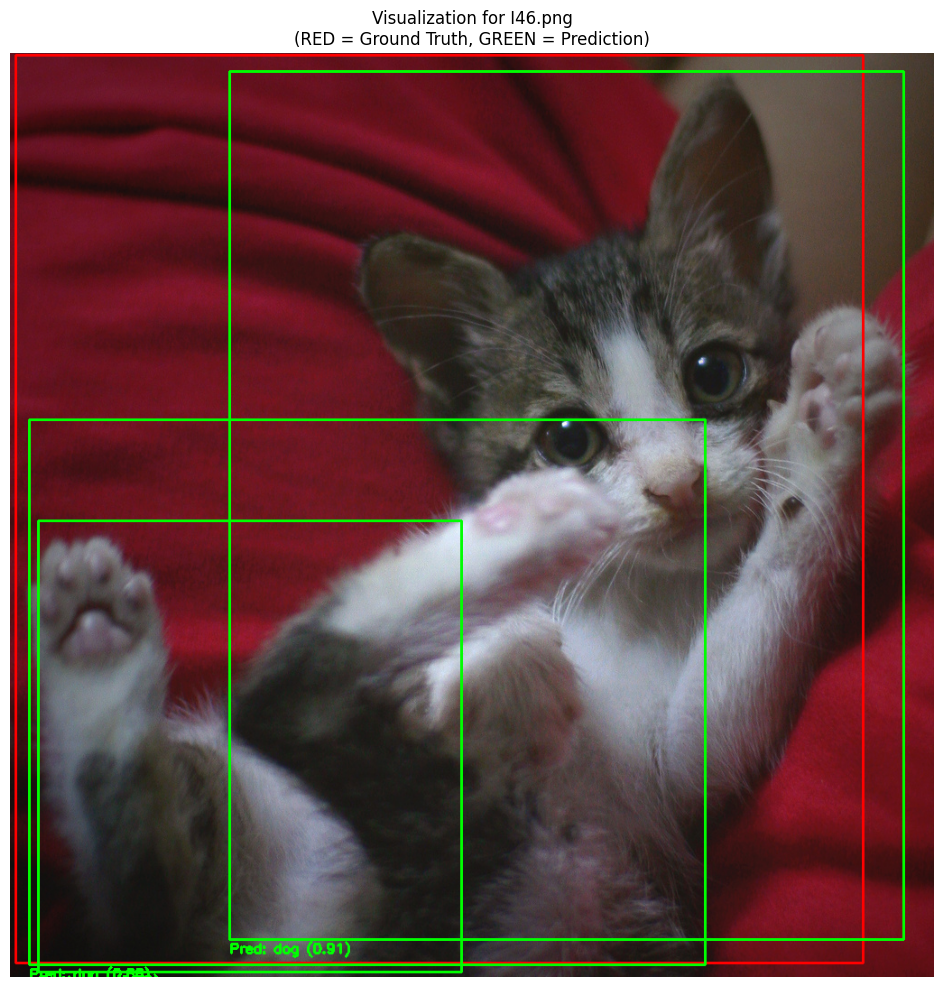

Processing 57/150: I27.png
Processing 58/150: I70.png
Processing 59/150: I55.png
Processing 60/150: I36.png
Processing 61/150: I32.png
Processing 62/150: I69.png
Processing 63/150: I45.png
Processing 64/150: I34.png
Processing 65/150: I75.png
Processing 66/150: I23.png
Processing 67/150: I74.png
Processing 68/150: I72.png
Processing 69/150: I68.png
Processing 70/150: I42.png
Processing 71/150: I19.png
Processing 72/150: I38.png
Processing 73/150: I51.png
Processing 74/150: I18.png
Processing 75/150: I62.png
Processing 76/150: I100.png
Processing 77/150: I132.png
Processing 78/150: I129.png
Processing 79/150: I78.png
Processing 80/150: I124.png
Processing 81/150: I117.png
Processing 82/150: I102.png
Processing 83/150: I88.png
Processing 84/150: I123.png
Processing 85/150: I104.png
Processing 86/150: I125.png
Processing 87/150: I135.png
Processing 88/150: I110.png
Processing 89/150: I112.png
Processing 90/150: I138.png
Processing 91/150: I116.png
Processing 92/150: I111.png
Processing 93

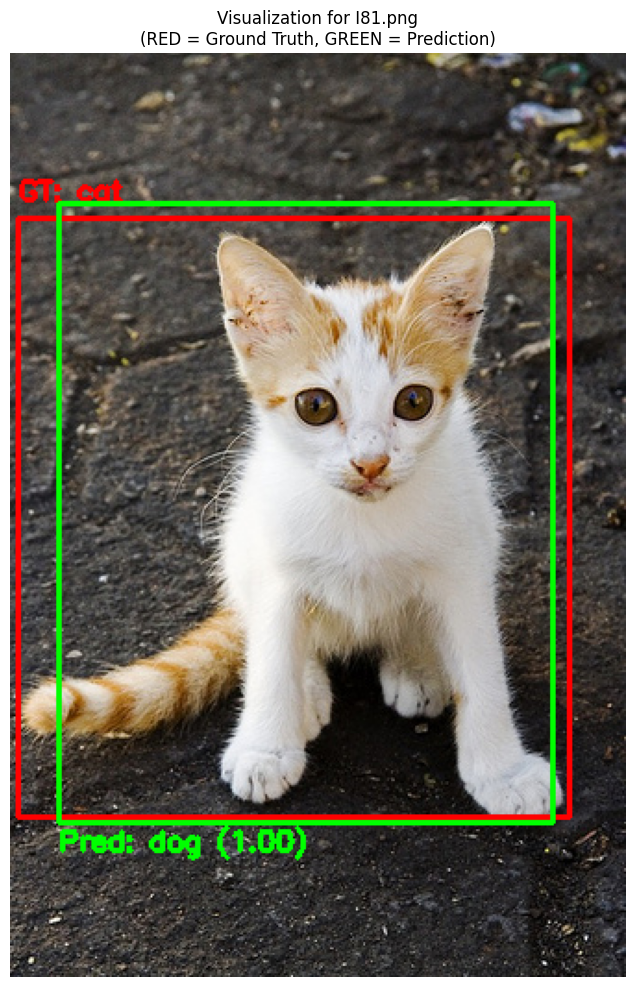

Processing 94/150: I97.png
Processing 95/150: I114.png
Processing 96/150: I90.png
Processing 97/150: I99.png
Processing 98/150: I103.png
Processing 99/150: I141.png
Processing 100/150: I119.png
Processing 101/150: I106.png
Processing 102/150: I83.png
Processing 103/150: I121.png


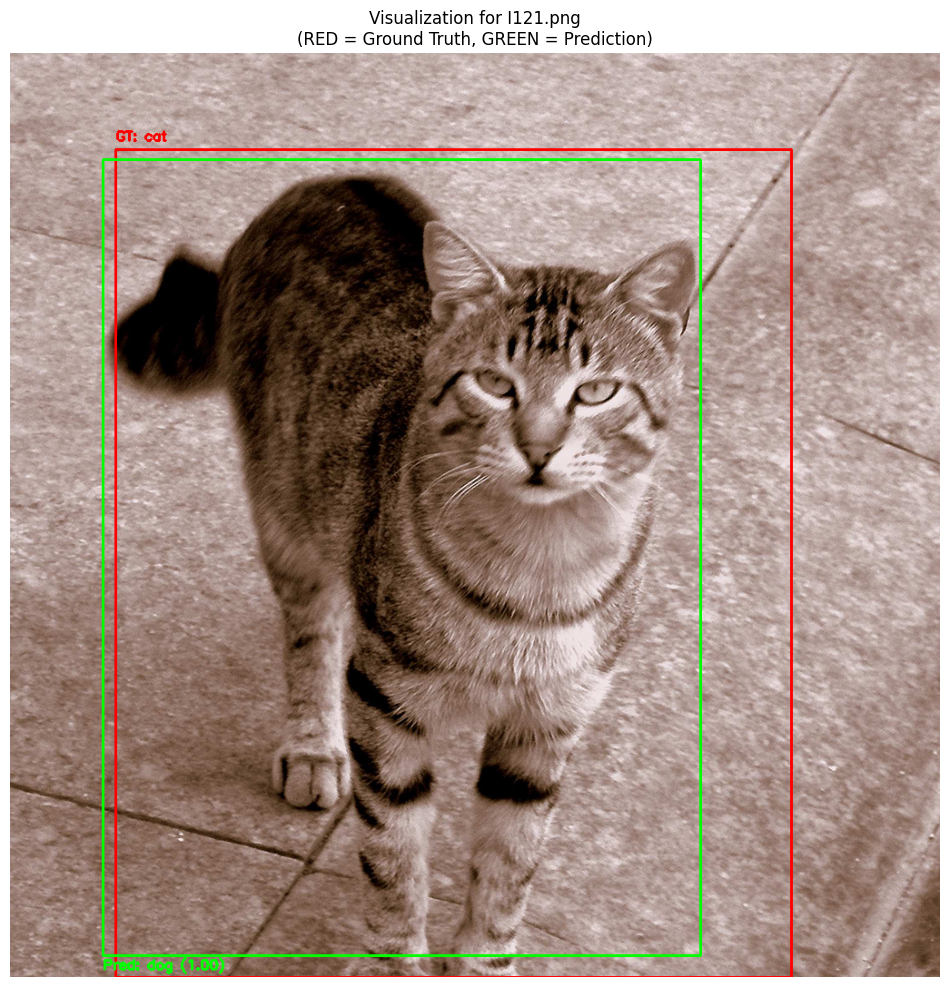

Processing 104/150: I91.png
Processing 105/150: I79.png
Processing 106/150: I142.png
Processing 107/150: I130.png
Processing 108/150: I120.png
Processing 109/150: I140.png
Processing 110/150: I118.png
Processing 111/150: I107.png
Processing 112/150: I127.png
Processing 113/150: I122.png
Processing 114/150: I126.png
Processing 115/150: I96.png
Processing 116/150: I85.png
Processing 117/150: I133.png
Processing 118/150: I108.png
Processing 119/150: I131.png
Processing 120/150: I86.png
Processing 121/150: I139.png
Processing 122/150: I134.png
Processing 123/150: I109.png
Processing 124/150: I89.png
Processing 125/150: I87.png


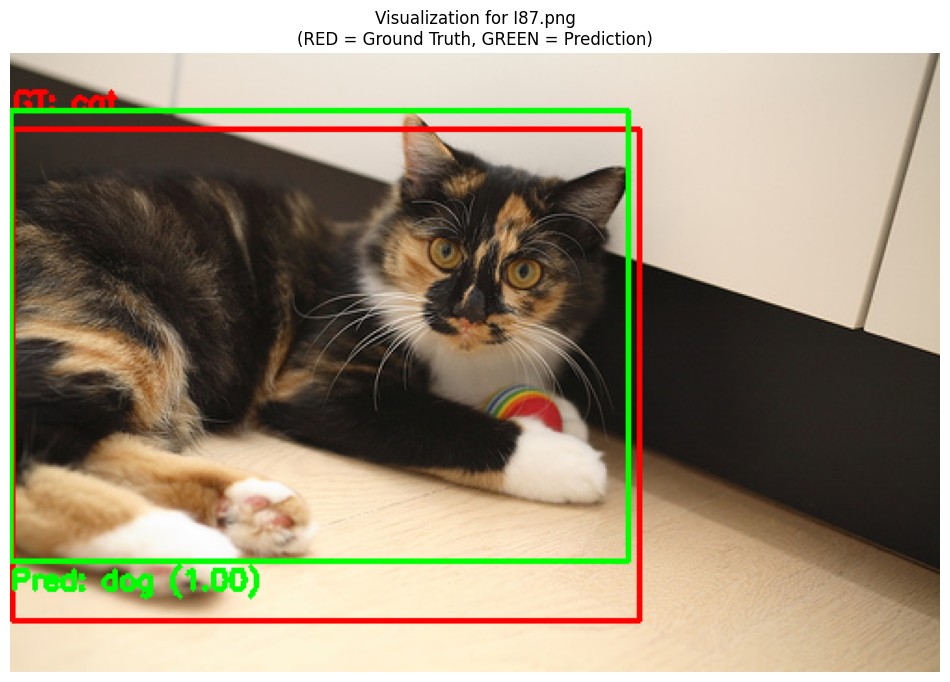

Processing 126/150: I136.png
Processing 127/150: I84.png
Processing 128/150: I94.png
Processing 129/150: I101.png
Processing 130/150: I82.png
Processing 131/150: I128.png
Processing 132/150: I113.png
Processing 133/150: I98.png
Processing 134/150: I93.png
Processing 135/150: I115.png
Processing 136/150: I95.png
Processing 137/150: I137.png
Processing 138/150: I92.png
Processing 139/150: I150.png
Processing 140/150: I154.png
Processing 141/150: I147.png


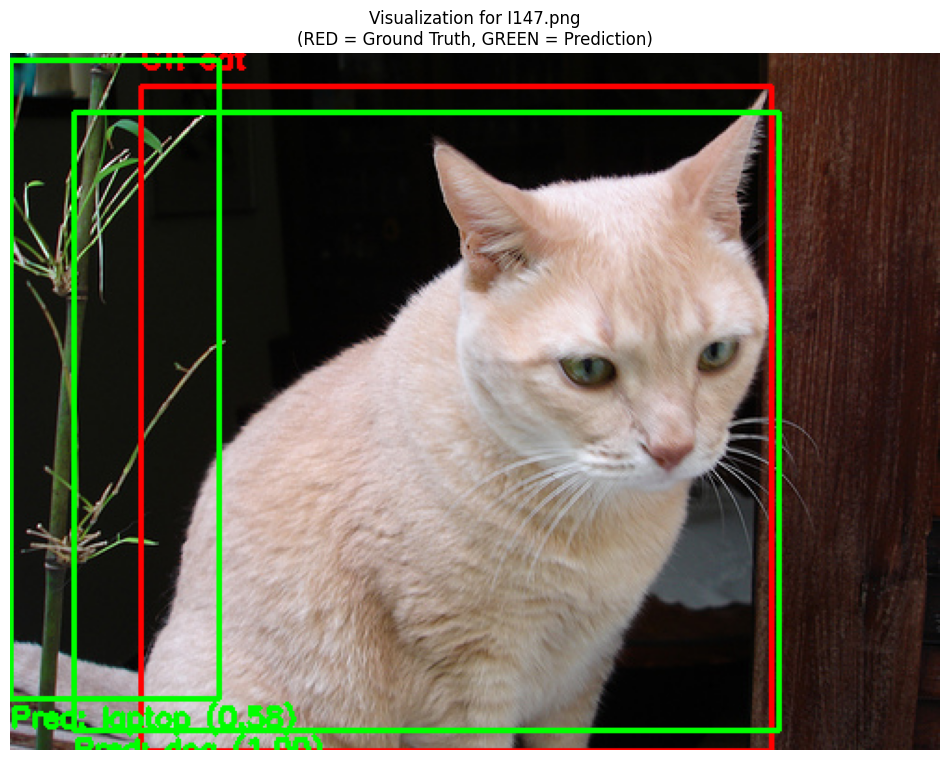

Processing 142/150: I153.png
Processing 143/150: I144.png
Processing 144/150: I145.png
Processing 145/150: I143.png
Processing 146/150: I146.png
Processing 147/150: I152.png
Processing 148/150: I149.png
Processing 149/150: I148.png
Processing 150/150: I151.png

 Calculating AP per class 
Class 'cat': AP = 0.0303

Mean Average Precision (mAP@0.5): 0.0303

 Final Results 
Evaluated on dataset at: /content/drive/MyDrive/Cat/images
Confidence Threshold: 0.5
IoU Threshold: 0.5
mAP: 0.0303

Per-class AP for classes found in my dataset:
  cat: 0.0303


In [6]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path
import glob # Added for file searching
import xml.etree.ElementTree as ET # Added for XML parsing
import random # Added for visualization

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# Step 1: Loading COCO class labels
def load_coco_labels():
    """Load COCO dataset class labels"""
    labels = [
        'background', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
        'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
        'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
        'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
        'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
        'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
        'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
        'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]
    return labels

# Step 2: Load pre-trained model
def load_model():
    """Load Faster R-CNN model from TensorFlow Hub"""
    print("Loading Faster R-CNN model...")
    model_url = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
    model = hub.load(model_url)
    print("Model loaded successfully!")
    return model

# Step 3: Calculate IoU (Intersection over Union)
def calculate_iou(box1, box2):
    y1_min, x1_min, y1_max, x1_max = box1
    y2_min, x2_min, y2_max, x2_max = box2

    x_left = max(x1_min, x2_min)
    y_top = max(y1_min, y2_min)
    x_right = min(x1_max, x2_max)
    y_bottom = min(y1_max, y2_max)

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0
    return iou

# Step 4: Perform detection on single image
def detect_objects(model, image_path, confidence_threshold=0.5):
    try:
        img = Image.open(image_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        image_np = np.array(img)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

    input_tensor = tf.convert_to_tensor(image_np)
    input_tensor = input_tensor[tf.newaxis, ...]
    detections = model(input_tensor)

    num_detections = int(detections.pop('num_detections'))
    detections = {key: value[0, :num_detections].numpy()
                  for key, value in detections.items()}

    indices = detections['detection_scores'] >= confidence_threshold
    filtered_detections = {
        'boxes': detections['detection_boxes'][indices],
        'classes': detections['detection_classes'][indices].astype(int),
        'scores': detections['detection_scores'][indices]
    }
    return filtered_detections

# Step 5: Calculate Average Precision for a single class
def calculate_ap(predictions, ground_truths, iou_threshold=0.5):
    """Calculate Average Precision (AP) for a single class"""
    if len(ground_truths) == 0: return 0.0
    if len(predictions) == 0: return 0.0

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    gt_matched = [False] * len(ground_truths)
    tp = []
    fp = []

    for pred_box, pred_score in predictions:
        max_iou = 0
        max_idx = -1
        for gt_idx, gt_box in enumerate(ground_truths):
            if gt_matched[gt_idx]: continue
            iou = calculate_iou(pred_box, gt_box)
            if iou > max_iou:
                max_iou = iou
                max_idx = gt_idx

        if max_iou >= iou_threshold and max_idx != -1:
            if not gt_matched[max_idx]:
                tp.append(1)
                fp.append(0)
                gt_matched[max_idx] = True
            else:
                tp.append(0)
                fp.append(1)
        else:
            tp.append(0)
            fp.append(1)

    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)
    recalls = tp_cumsum / len(ground_truths)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-9)

    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))

    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    ap = 0.0
    for t in np.linspace(0, 1, 11):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11
    return ap


# Visualize predictions vs. ground truth
def draw_boxes_on_image(image_path, detections, gt_data, coco_labels, image_file_name):
    """Draws predicted (green) and ground truth (red) boxes on an image."""

    # Load image with OpenCV
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image {image_path} for visualization.")
        return

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image.shape

    # 1. Draw Ground Truth Boxes (RED)
    for gt_box, gt_cls in gt_data:
        # Un-normalize coordinates
        ymin, xmin, ymax, xmax = gt_box
        xmin = int(xmin * width)
        xmax = int(xmax * width)
        ymin = int(ymin * height)
        ymax = int(ymax * height)

        # Draw box
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2) # Red
        # Draw label
        label = f"GT: {coco_labels[gt_cls]}"
        cv2.putText(image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # 2. Draw Predicted Boxes (GREEN)
    for box, cls, score in zip(detections['boxes'], detections['classes'], detections['scores']):
        # Un-normalize coordinates
        ymin, xmin, ymax, xmax = box
        xmin = int(xmin * width)
        xmax = int(xmax * width)
        ymin = int(ymin * height)
        ymax = int(ymax * height)

        # Draw box
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2) # Green
        # Draw label
        label = f"Pred: {coco_labels[cls]} ({score:.2f})"
        cv2.putText(image, label, (xmin, ymax + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 3. Display Image
    plt.figure(figsize=(12, 12))
    plt.imshow(image)
    plt.title(f"Visualization for {image_file_name}\n(RED = Ground Truth, GREEN = Prediction)")
    plt.axis('off')
    plt.show()

# STEP 7
# Batch evaluation function
def batch_evaluate(model, image_dir, ground_truth_annotations, confidence_threshold=0.5, iou_threshold=0.5, visualize_count=0):
    """Evaluate model on multiple images and calculate mAP"""
    labels = load_coco_labels()
    class_predictions = {i: [] for i in range(len(labels))}
    class_ground_truths = {i: [] for i in range(len(labels))}

    image_files = [f for f in os.listdir(image_dir)
                   if f.endswith(('.jpg', '.jpeg', '.png'))]

    annotated_files = [f for f in image_files if f in ground_truth_annotations]

    # Select random images to visualize
    files_to_visualize = random.sample(annotated_files, min(visualize_count, len(annotated_files)))
    if files_to_visualize:
        print(f"\nWill visualize {len(files_to_visualize)} random images.")

    print(f"\nFound {len(annotated_files)} images with corresponding annotations.")

    if not annotated_files:
        print("Error: No images found in the directory that match the annotation keys.")
        return 0.0, {}

    for idx, image_file in enumerate(annotated_files):
        print(f"Processing {idx+1}/{len(annotated_files)}: {image_file}")
        image_path = os.path.join(image_dir, image_file)

        detections = detect_objects(model, image_path, confidence_threshold)
        if detections is None:
            continue

        gt_data = ground_truth_annotations[image_file]

        # Call visualization if file is in our random list
        if image_file in files_to_visualize:
            draw_boxes_on_image(image_path, detections, gt_data, labels, image_file)

        # Organize predictions by class
        for box, cls, score in zip(detections['boxes'], detections['classes'], detections['scores']):
            if cls < len(labels):
                class_predictions[cls].append((box, score))

        # Organize ground truths by class
        for gt_box, gt_cls in gt_data:
            if gt_cls < len(labels):
                class_ground_truths[gt_cls].append(gt_box)

    class_aps = {}
    valid_classes = 0

    print("\n Calculating AP per class ")
    for class_id in range(len(labels)):
        if len(class_ground_truths[class_id]) > 0:
            ap = calculate_ap(
                class_predictions[class_id],
                class_ground_truths[class_id],
                iou_threshold
            )
            class_aps[labels[class_id]] = ap
            valid_classes += 1
            print(f"Class '{labels[class_id]}': AP = {ap:.4f}")

    if valid_classes > 0:
        mAP = sum(class_aps.values()) / valid_classes
    else:
        mAP = 0.0
        print("No ground truth classes found to evaluate.")

    print(f"\n{'='*50}")
    print(f"Mean Average Precision (mAP@{iou_threshold}): {mAP:.4f}")
    print(f"{'='*50}")

    return mAP, class_aps

#  STEP 8
# Load REAL annotations from your Cat dataset
def load_catflw_annotations(annotations_dir, class_mapping):
    """Loads Cat XML annotations and converts them to the required format."""
    print(f"\nLoading annotations from: {annotations_dir}")
    annotations = {}
    xml_files = glob.glob(os.path.join(annotations_dir, "*.xml"))

    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            filename = root.find("filename").text
            size_elem = root.find("size")
            width = int(size_elem.find("width").text)
            height = int(size_elem.find("height").text)

            if width == 0 or height == 0:
                print(f"Warning: Skipping {filename}, invalid dimensions (width or height is 0).")
                continue

            image_annotations = []
            for obj in root.findall("object"):
                class_name = obj.find("name").text
                if class_name in class_mapping:
                    class_id = class_mapping[class_name]

                    bndbox = obj.find("bndbox")
                    xmin = int(bndbox.find("xmin").text)
                    ymin = int(bndbox.find("ymin").text)
                    xmax = int(bndbox.find("xmax").text)
                    ymax = int(bndbox.find("ymax").text)

                    # Normalize and convert to [ymin, xmin, ymax, xmax]
                    normalized_box = [
                        ymin / height,
                        xmin / width,
                        ymax / height,
                        xmax / width
                    ]

                    image_annotations.append((normalized_box, class_id))

            if image_annotations:
                annotations[filename] = image_annotations
        except Exception as e:
            print(f"Error parsing {xml_file}: {e}")

    print(f"Loaded {len(annotations)} annotation files.")
    return annotations


# --- Main execution ---
if __name__ == "__main__":

    # Configuration
    IMAGE_DIR = '/content/drive/MyDrive/Cat/images'
    ANNOTATIONS_DIR = '/content/drive/MyDrive/Cat/Annotation'

    confidence_threshold = 0.5
    iou_threshold = 0.5

    #  Visualization of images
    VISUALIZE_COUNT = 5


    # Load model
    model = load_model()

    # Define the class mapping: "cat" is ID 16 in the COCO labels list
    cat_class_mapping = {"cat": 16}

    # Load your REAL ground truth annotations
    ground_truth = load_catflw_annotations(ANNOTATIONS_DIR, cat_class_mapping)

    # Perform batch evaluation
    mAP, class_aps = batch_evaluate(
        model,
        IMAGE_DIR,
        ground_truth,
        confidence_threshold,
        iou_threshold,
        visualize_count=VISUALIZE_COUNT # Pass the new parameter
    )

    # Display results
    print("\n Final Results ")
    print(f"Evaluated on dataset at: {IMAGE_DIR}")
    print(f"Confidence Threshold: {confidence_threshold}")
    print(f"IoU Threshold: {iou_threshold}")
    print(f"mAP: {mAP:.4f}")

    print("\nPer-class AP for classes found in my dataset:")
    for class_name, ap in class_aps.items():
        print(f"  {class_name}: {ap:.4f}")